In [1]:
import numpy as np
import pandas as pd
import keras_tuner as kt
from tensorflow import keras
from tensorflow.keras import layers

In [2]:
import tensorflow as tf
import random

seed = 42

np.random.seed(seed)
tf.random.set_seed(seed)
random.seed(seed)

In [3]:
df = pd.read_csv('Data/data_preprocessing.csv', index_col='Date', parse_dates=True)
df.head()

,Precipitation,Temperature,Relative Humidity,Wind Speed
Date,,,,
1985-01-01,0.0,24.12,66.46,26.87
1985-01-02,0.0,24.27,66.08,26.60
1985-01-03,0.1,25.02,61.42,22.44
1985-01-04,0.2,25.26,60.54,22.89
1985-01-05,0.0,25.05,59.92,24.88


In [4]:
# Sắp xếp và kiểm tra dữ liệu
df = df.sort_index()

# kiểm tra liên tục thời gian
print(df.index.to_series().diff().value_counts().head())

Date
1 days    12204
Name: count, dtype: int64


In [5]:
# Chọn biến đầu vào & mục tiêu
features = ['Precipitation', 'Relative Humidity', 'Wind Speed']
target = 'Temperature'

X = df[features]
y = df[target]

In [6]:
# Chia tập dữ liệu: 70% train, 15% validation, 15% test
total_samples = len(X)
train_size = int(total_samples * 0.70)
val_size = int(total_samples * 0.15)

X_train = X[:train_size]
y_train = y[:train_size]

X_val = X[train_size:train_size + val_size]
y_val = y[train_size:train_size + val_size]

X_test = X[train_size + val_size:]
y_test = y[train_size + val_size:]

In [7]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (8543, 3)
y_train shape: (8543,)
X_val shape: (1830, 3)
y_val shape: (1830,)
X_test shape: (1832, 3)
y_test shape: (1832,)


In [8]:
from sklearn.preprocessing import MinMaxScaler
# Chuẩn hóa dữ liệu
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled   = scaler_X.transform(X_val)
X_test_scaled  = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1,1))
y_val_scaled   = scaler_y.transform(y_val.values.reshape(-1,1))
y_test_scaled  = scaler_y.transform(y_test.values.reshape(-1,1))

In [9]:
# Hàm tạo chuỗi dữ liệu > Dự đoán ngày tiếp theo
def create_sequences(X, y, time_step):
    X_seq, y_seq = [], []
    
    for i in range(len(X) - time_step):
        X_seq.append(X[i:i + time_step])
        y_seq.append(y[i + time_step])
        
    return np.array(X_seq), np.array(y_seq)

In [10]:
# Xác định time_step = 30 
time_step = 30

X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, time_step)
X_val_seq, y_val_seq     = create_sequences(X_val_scaled, y_val_scaled, time_step)
X_test_seq, y_test_seq   = create_sequences(X_test_scaled, y_test_scaled, time_step)

In [11]:
X_train_seq = X_train_seq.reshape((X_train_seq.shape[0], X_train_seq.shape[1], X_train_seq.shape[2]))
X_val_seq   = X_val_seq.reshape((X_val_seq.shape[0], X_val_seq.shape[1], X_val_seq.shape[2]))

In [12]:
print(X_train_seq.shape)
print(X_val_seq.shape)

(8513, 30, 3)
(1800, 30, 3)


In [13]:
def build_gru(hp):

    model = keras.Sequential([
        keras.Input(shape=(X_train_seq.shape[1], X_train_seq.shape[2])),

        layers.GRU(
            units=hp.Int("gru_units", 32, 128, step=32),
            return_sequences=False
        ),

        layers.Dense(1)
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(
            hp.Float("learning_rate", 1e-4, 1e-2, sampling="log")
        ),
        loss="mse",
        metrics=["mae"]
    )

    return model

In [14]:
# tuner_gru = kt.RandomSearch(
#     build_gru,
#     objective="val_loss",
#     max_trials=20,
#     executions_per_trial=1,
#     seed=42,
#     overwrite=True,
#     directory="hyperparameter_tuning",
#     project_name="gru_search"
# )
tuner_gru = kt.GridSearch(
    build_gru,
    objective="val_loss",
    executions_per_trial=1,
    seed=42,
    overwrite=True,
    directory="hyperparameter_tuning",
    project_name="gru_grid_search"
)

In [15]:
# tuner_gru.search(
#     X_train_seq,
#     y_train_seq,
#     epochs=50,
#     validation_data=(X_val_seq, y_val_seq),
#     batch_size=32
# 
tuner_gru.search(
    X_train_seq,
    y_train_seq,
    epochs=20,
    validation_data=(X_val_seq, y_val_seq),
    batch_size=32,
    shuffle=False
)

Trial 44 Complete [00h 01m 29s]
val_loss: 0.007336006034165621

Best val_loss So Far: 0.006757079157978296
Total elapsed time: 00h 57m 06s


In [16]:
best_model = tuner_gru.get_best_models(num_models=1)[0]

C:\Users\user\anaconda3\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 12 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [17]:
# best_gru_hp = tuner_gru.get_best_hyperparameters(num_trials=1)[0]

# print("Best units:", best_gru_hp.get("units"))
# print("Best learning rate:", best_gru_hp.get("learning_rate"))

In [18]:
best_hp = tuner_gru.get_best_hyperparameters(1)[0]
print(best_hp.values)

{'gru_units': 64, 'learning_rate': 0.0050118723362727255}


In [19]:
best_model_gru= tuner_gru.hypermodel.build(best_hp)

In [20]:
best_model_gru.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ gru_1 (GRU)                          │ (None, 64)                  │          13,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 13,313 (52.00 KB)

 Trainable params: 13,313 (52.00 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

In [32]:
history = best_model_gru.fit(
    X_train_seq,
    y_train_seq,
    epochs=50,
    validation_data=(X_val_seq, y_val_seq),
    batch_size=32,
    shuffle=False,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0090 - mae: 0.0750 - val_loss: 0.0075 - val_mae: 0.0681
Epoch 2/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0085 - mae: 0.0726 - val_loss: 0.0074 - val_mae: 0.0678
Epoch 3/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0084 - mae: 0.0718 - val_loss: 0.0076 - val_mae: 0.0690
Epoch 4/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - loss: 0.0083 - mae: 0.0713 - val_loss: 0.0078 - val_mae: 0.0697
Epoch 5/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0082 - mae: 0.0709 - val_loss: 0.0080 - val_mae: 0.0710
Epoch 6/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0081 - mae: 0.0705 - val_loss: 0.0078 - val_mae: 0.0703
Epoch 7/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0080 - mae: 0.0699 - val_loss: 0.0079 - val_mae: 0.0708
Epoch 8/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0081 - mae: 0.0701 - val_loss: 0.0081 - val_mae: 0.0713
Epoch 9/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/

In [33]:
y_pred_scaled = best_model_gru.predict(X_test_seq)

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


In [34]:
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_original = scaler_y.inverse_transform(y_test_seq)

In [35]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

mse = mean_squared_error(y_test_original, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_original, y_pred)
r2 = r2_score(y_test_original, y_pred)

print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)

RMSE: 1.1475343072808417
MAE: 0.8943744876196857
R2: 0.5067186551417227


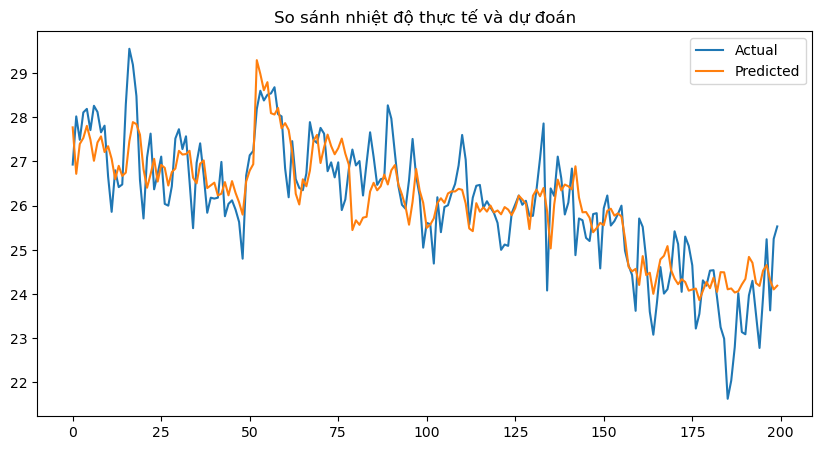

In [36]:
# Vẽ biểu đồ so sánh Thực tế vs Dự đoán
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(y_test_original[:200], label="Actual")
plt.plot(y_pred[:200], label="Predicted")
plt.legend()
plt.title("So sánh nhiệt độ thực tế và dự đoán")
plt.show()

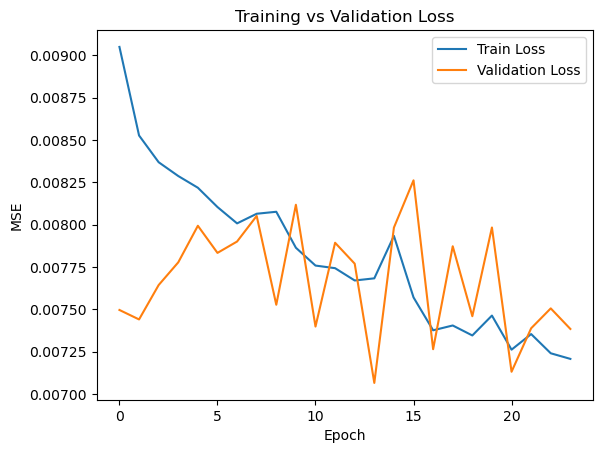

In [37]:
# Vẽ biểu đồ Loss trong quá trình train
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Training vs Validation Loss")
plt.show()

In [38]:
mape = np.mean(np.abs((y_test_original - y_pred) / y_test_original)) * 100
print(f"Sai số phần trăm trung bình (MAPE): {mape:.2f}%")

Sai số phần trăm trung bình (MAPE): 3.39%


In [39]:
accuracy = 100 - mape
print(f"Độ chính xác (Accuracy): {accuracy:.2f}%")

Độ chính xác (Accuracy): 96.61%


In [41]:
best_model_gru.save("best_module_gru.keras")